In [1]:
print("Hello World")

Hello World


In [101]:
TOGETHER_BASE_URL="https://api.together.ai/v1"
TOGETHER_API_KEY=""
OPENAI_OSS_MODEL="OpenAI/gpt-oss-20B"
LIQUID_AI="LiquidAI/LFM2-24B-A2B"
QWEN="Qwen/Qwen3.5-9B"
TAVILY_API_KEY=""

In [102]:
import requests
from langchain.tools import tool
from langchain_tavily import TavilySearch
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, END, START

In [ ]:
llm = ChatOpenAI(
  model=QWEN,
  api_key=TOGETHER_API_KEY,
  base_url=TOGETHER_BASE_URL
)

In [104]:
@tool(
    "calculator",
    description=(
        "Performs arithmetic and mathematical calculations. "
        "Use this tool for evaluating math expressions, basic arithmetic, "
        "scientific calculations, or solving numeric problems. "
        "Input should be a valid mathematical expression as a string "
        "(e.g., '25 * 4 + 10', 'sqrt(16)', '100 / 5'). "
        "Do NOT use for general reasoning, factual queries, or web lookups."
    )
)
def calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    return str(eval(expression))


@tool(
    "web_search",
    description=(
        "Searches the web for up-to-date or factual information. "
        "Use this tool when the question requires recent data, external knowledge, "
        "current events, factual lookups, company/product information, "
        "documentation, or anything not guaranteed to be in memory. "
        "Input should be a concise search query "
        "(e.g., 'latest LangChain version', 'weather in Hyderabad'). "
        "Do NOT use for math calculations or simple reasoning."
    )
)
def web_search(query: str):
    response = TavilySearch(
        max_results=3,
        topic="general",
        tavily_api_key=TAVILY_API_KEY
        
    )
    return response.invoke(query)


@tool(
    "weather",
    description=(
        "Fetches real-time weather information for a specific location. "
        "Use this tool when the user asks about current weather conditions, "
        "temperature, humidity, rain, wind, or weather forecasts for a city or place. "
        "Input should be a location name as a string "
        "(e.g., 'Hyderabad', 'New York', 'London'). "
        "Use for weather-related questions like "
        "'What's the weather in Mumbai?' or "
        "'Is it raining in Bangalore?'. "
        "Do NOT use for general knowledge, math, or non-weather queries."
    )
)
def get_weather(location: str) -> str:
    url = f"https://wttr.in/{location}?format=j1"
    response = requests.get(url, timeout=10)

    response.raise_for_status()
    data = response.json()

    return data

# calc.invoke("2+2")
# web_search.invoke("HDFC")
# get_weather.invoke("Hyderabad")
all_tools = [calc, web_search, get_weather]

## Agent Node

In [79]:
import operator
from typing import Annotated, TypedDict


class AgentState(TypedDict):
  messages: Annotated[list, operator.add]

def agent_node(state:AgentState):
  messages = state['messages']
  llm_with_tools = llm.bind_tools(all_tools)
  response = llm_with_tools.invoke(messages)

  if hasattr(response, "tool_calls") and response.tool_calls:
    for tc in response.tool_calls:
      print(f"[AGENT] called Tool {tc.get("name", '?')} with args {tc.get('args', '?')}")
  else:
    print("[AGENT] Final Response....")

  return {
    "messages": [response]
  }

def should_continue(state:AgentState):
  last_message = state['messages'][-1]
  if hasattr(last_message, "tool_calls") and last_message.tool_calls:
    return "tools"
  return END

In [85]:
def create_agent():
  builder = StateGraph(AgentState)
  builder.add_node("agent", agent_node)
  builder.add_node("tools", ToolNode(all_tools))

  builder.add_edge(START, "agent")
  builder.add_conditional_edges("agent", should_continue, ['tools', END])
  builder.add_edge("tools", "agent")
  graph = builder.compile()
  return graph

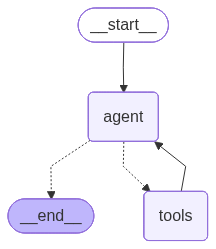

In [86]:
create_agent()

In [98]:
query_1="Hi"
query_2="WHat is the Weather of Hyderabad?"
query_3="WHat is 2+2?"
query_4 = "What is the weather in Mumbai? and What is 4*56 and 3-90 and What is the Latest News on HDFC Math?"


In [99]:
from langchain_core.messages import HumanMessage


resp = create_agent().invoke({'messages': [HumanMessage(query_4)]})

[AGENT] called Tool weather with args {'location': 'Mumbai'}
[AGENT] called Tool calculator with args {'expression': '4*56'}
[AGENT] called Tool calculator with args {'expression': '3-90'}
[AGENT] called Tool web_search with args {'query': 'HDFC bank latest news'}
[AGENT] Final Response....


In [100]:

for message in resp['messages']:
  message.pretty_print() 

================================ Human Message =================================

What is the weather in Mumbai? and What is 4*56 and 3-90 and What is the Latest News on HDFC Math?
================================== Ai Message ==================================
Tool Calls:
  weather (call_90de8b3c00bf423fa09b62eb)
 Call ID: call_90de8b3c00bf423fa09b62eb
  Args:
    location: Mumbai
  calculator (call_14a85f41d7da412bb40ac5a8)
 Call ID: call_14a85f41d7da412bb40ac5a8
  Args:
    expression: 4*56
  calculator (call_012ecaf04ca0454da6b72319)
 Call ID: call_012ecaf04ca0454da6b72319
  Args:
    expression: 3-90
  web_search (call_e4ffe1033d1e4d68b3826af9)
 Call ID: call_e4ffe1033d1e4d68b3826af9
  Args:
    query: HDFC bank latest news
================================= Tool Message =================================
Name: weather

{"current_condition": [{"FeelsLikeC": "40", "FeelsLikeF": "105", "cloudcover": "50", "humidity": "71", "observation_time": "03:55 PM", "precipInches": "0.0", "precip